# Exploratory Data Analysis
## Requested Analysis  
### Action 1
*Further interrogate the figures in BUS01e and produce a graph comparing total bus patronage growth in Warwickshire between 2022 - 2025 to that in other similar neighbouring Local Authority areas, i.e. Worcestershire, Staffordshire, West Northamptonshire, Shropshire, Gloucestershire, Leicestershire and Oxfordshire.*

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def year_formatter(x, pos):
    return f"{int(x)}"


df = pd.read_csv('data/BUS01e.csv')
df.head()

,Local Authority (LA) Code,LA or Region,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,E12000001,North East,207.2,205.6,198.6,190.4,188.3,184.9,180.6,177.0,169.0,171.6,159.8,61.2,113.0,130.2,130.3,139.2
1,E06000005,Darlington,8.2,7.9,7.0,6.6,6.6,6.5,6.2,6.3,6.0,5.7,5.5,1.7,3.6,4.3,4.1,4.1
2,E06000047,Durham,26.3,25.9,24.7,23.1,23.2,22.8,22.1,21.9,21.7,22.1,20.8,8.7,17.6,17.3,17.2,17.7
3,E06000001,Hartlepool,5.4,5.3,4.8,4.6,4.6,4.7,4.7,4.4,4.3,4.4,4.0,1.6,2.8,3.5,3.6,3.5
4,E06000002,Middlesbrough,10.2,10.4,9.8,9.1,9.0,8.4,9.1,8.4,7.3,7.4,6.8,2.5,4.8,5.9,6.6,6.5


In [4]:
# Cleaning and preparing data for analysis
year_cols = [c for c in df.columns if c.isdigit()]

df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passenger_Journeys_Millions"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["Passenger_Journeys_Millions"] = pd.to_numeric(
    df_long["Passenger_Journeys_Millions"],
    errors="coerce"
)

# Keep only 2022–2025
df_long = df_long[df_long["Year"].between(2022, 2025)]

target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]

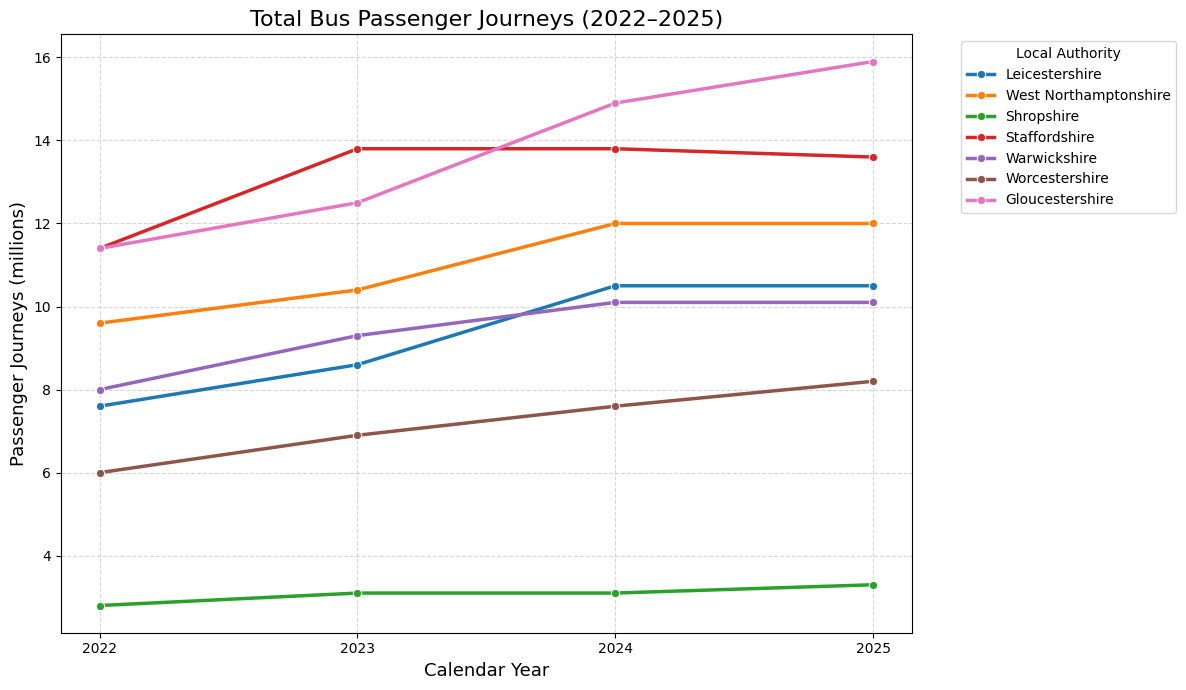

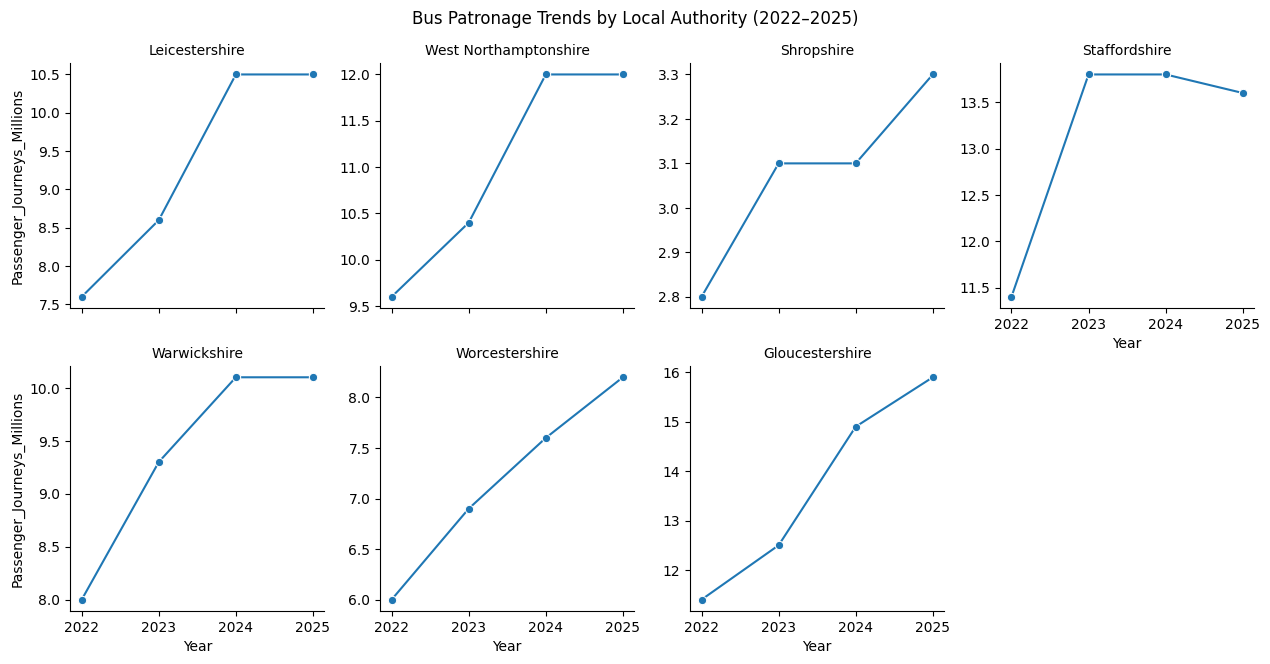

LA or Region,Gloucestershire,Leicestershire,Shropshire,Staffordshire,Warwickshire,West Northamptonshire,Worcestershire
Percentage increase 2022–25,39.5%,38.2%,17.9%,19.3%,26.2%,25.0%,36.7%


In [38]:
# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Passenger_Journeys_Millions",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Total Bus Passenger Journeys (2022–2025)", fontsize=16)
plt.xlabel("Calendar Year", fontsize=13)
plt.ylabel("Passenger Journeys (millions)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))

ax = plt.gca()

years = sorted(df_filtered["Year"].unique())
ax.set_xticks(years)
ax.set_xticklabels(years)

ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))


plt.tight_layout()
plt.show()


# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Passenger_Journeys_Millions", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Bus Patronage Trends by Local Authority (2022–2025)", y=1.03)

plt.show()

df_22_25 = df_filtered[df_filtered["Year"].isin([2022, 2025])]

pivot = df_22_25.pivot(
    index="Year",
    columns="LA or Region",
    values="Passenger_Journeys_Millions"
)

pct_change = ((pivot.loc[2025] - pivot.loc[2022]) / pivot.loc[2022]) * 100

final_df = pct_change.to_frame("Percentage increase 2022–25").T
final_df = final_df.round(2)

df_styled = (
    final_df
    .style
    .format("{:.1f}%")   # ← one decimal place + percent sign
    .apply(
        lambda col: ["background-color: grey"] * len(col)
        if col.name == "Warwickshire"
        else ["" for _ in col],
        axis=0
    )
)
df_styled




### Action 2
**Interrogate all other Warwickshire specific based data in the document, i.e., BUS01f (Bus Passenger Journeys on Local Bus Services per head by Local Authority), and BUS01g (Elderly and Disabled Concessionary Passenger Journeys on Local Bus Services by Local Authority), and BUS01h (Elderly and Disabled Concessionary Passenger Journeys on Local Bus Services by Local Authority as a Percentage of Total Passenger Journeys), and conduct the following tasks:** 

*Extrapolate the respective data into graphs replicating that already produced for BUS01e above; interrogate the respective figures and produce a graph comparing figures for Warwickshire between 2022 - 2025 to that in other similar neighbouring Local Authority areas, i.e. Worcestershire, Staffordshire, West Northamptonshire, Shropshire, Gloucestershire and Leicestershire and Oxfordshire*

**BUS01f**

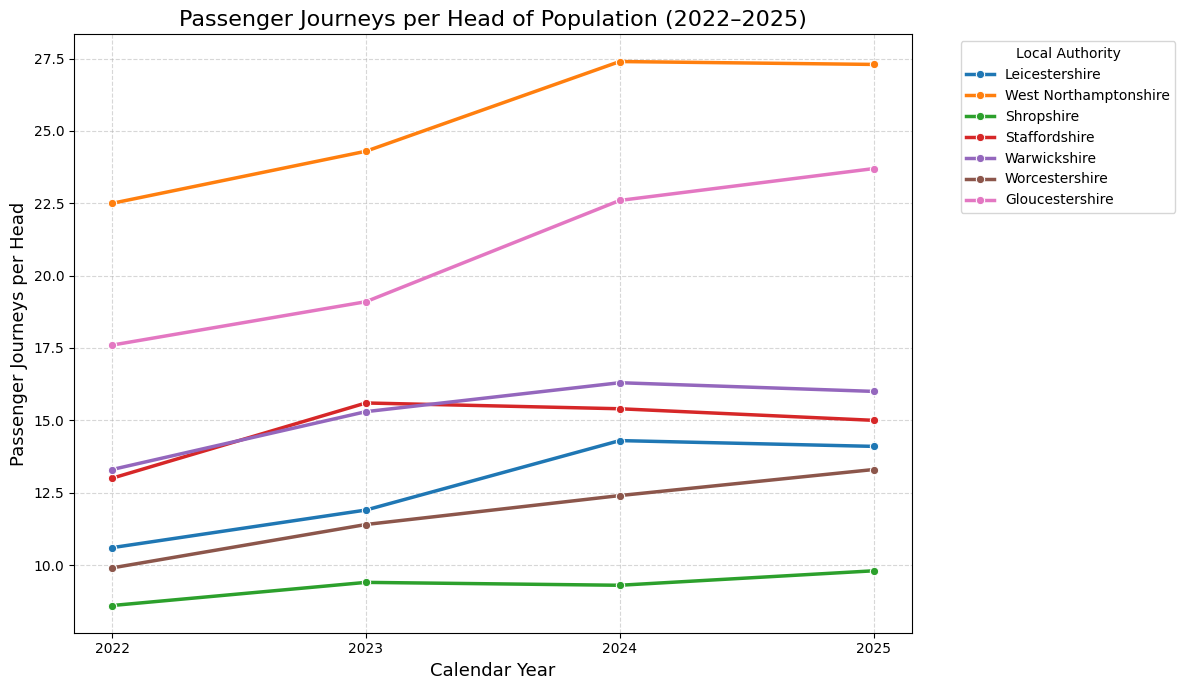

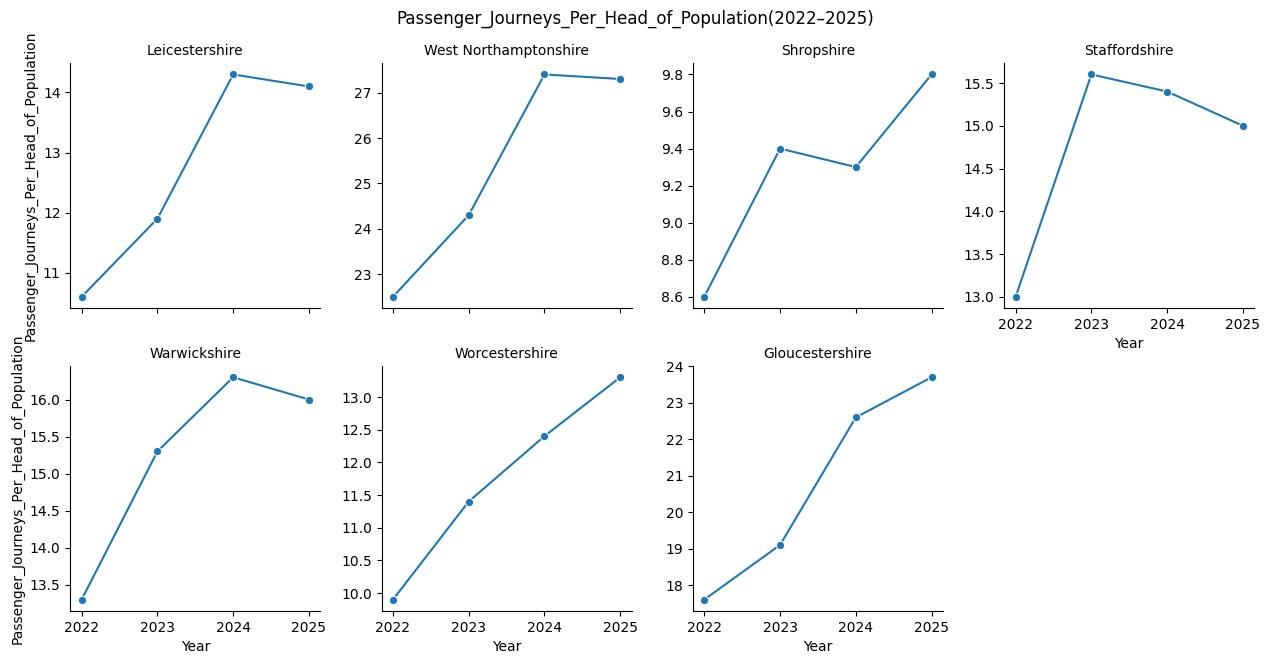

LA or Region,Gloucestershire,Leicestershire,Shropshire,Staffordshire,Warwickshire,West Northamptonshire,Worcestershire
Percentage increase 2022–25,34.7%,33.0%,13.9%,15.4%,20.3%,21.3%,34.3%


In [40]:
df = pd.read_csv("data/BUS01f.csv")

year_cols = [c for c in df.columns if c.isdigit()]

df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passenger_Journeys_Per_Head_of_Population"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["Passenger_Journeys_Per_Head_of_Population"] = pd.to_numeric(
    df_long["Passenger_Journeys_Per_Head_of_Population"],
    errors="coerce"
)

df_long = df_long[df_long["Year"].between(2022, 2025)]
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]
# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Passenger_Journeys_Per_Head_of_Population",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Passenger Journeys per Head of Population (2022–2025)", fontsize=16)
plt.xlabel("Calendar Year", fontsize=13)
plt.ylabel("Passenger Journeys per Head", fontsize=13)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1))

ax = plt.gca()

years = sorted(df_filtered["Year"].unique())
ax.set_xticks(years)
ax.set_xticklabels(years)

ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))

plt.tight_layout()
plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Passenger_Journeys_Per_Head_of_Population", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Passenger_Journeys_Per_Head_of_Population(2022–2025)", y=1.03)

plt.show()

df_22_25 = df_filtered[df_filtered["Year"].isin([2022, 2025])]

pivot = df_22_25.pivot(
    index="Year",
    columns="LA or Region",
    values="Passenger_Journeys_Per_Head_of_Population"
)

pct_change = ((pivot.loc[2025] - pivot.loc[2022]) / pivot.loc[2022]) * 100

final_df = pct_change.to_frame("Percentage increase 2022–25").T
final_df = final_df.round(2)

df_styled = (
    final_df
    .style
    .format("{:.1f}%")   # ← one decimal place + percent sign
    .apply(
        lambda col: ["background-color: grey"] * len(col)
        if col.name == "Warwickshire"
        else ["" for _ in col],
        axis=0
    )
)
df_styled

**BUS01g**

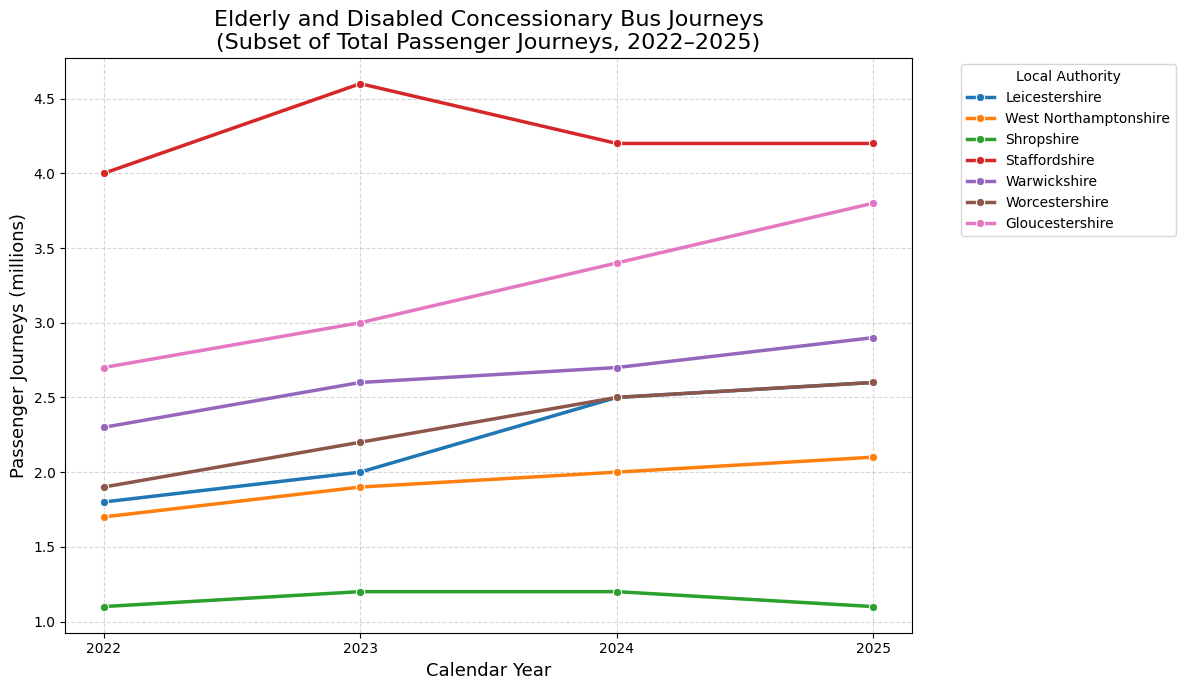

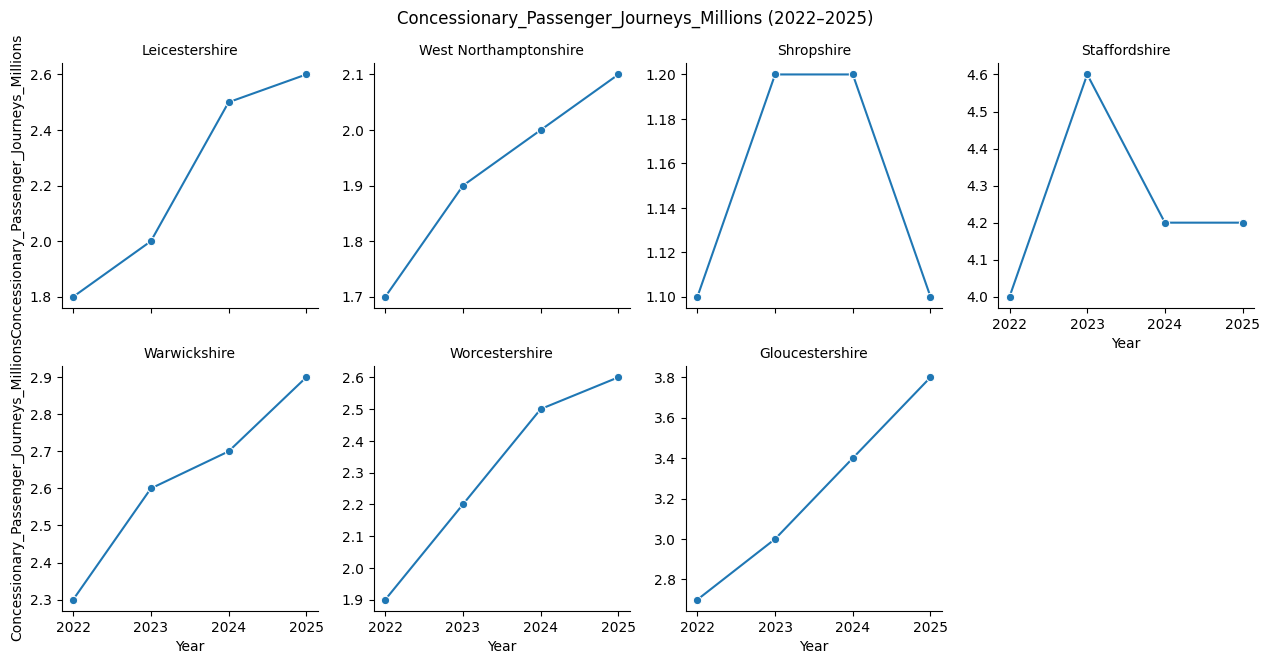

LA or Region,Gloucestershire,Leicestershire,Shropshire,Staffordshire,Warwickshire,West Northamptonshire,Worcestershire
Percentage increase 2022–25,40.7%,44.4%,0.0%,5.0%,26.1%,23.5%,36.8%


In [41]:
df = pd.read_csv("data/BUS01g.csv")

year_cols = [c for c in df.columns if c.isdigit()]

df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Concessionary_Passenger_Journeys_Millions"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["Concessionary_Passenger_Journeys_Millions"] = pd.to_numeric(
    df_long["Concessionary_Passenger_Journeys_Millions"],
    errors="coerce"
)


df_long = df_long[df_long["Year"].between(2022, 2025)]
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]

# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Concessionary_Passenger_Journeys_Millions",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Elderly and Disabled Concessionary Bus Journeys\n"
    "(Subset of Total Passenger Journeys, 2022–2025)",
    fontsize=16
)

plt.xlabel("Calendar Year", fontsize=13)
plt.ylabel("Passenger Journeys (millions)", fontsize=13)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1))

ax = plt.gca()

years = sorted(df_filtered["Year"].unique())
ax.set_xticks(years)
ax.set_xticklabels(years)

ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))


plt.tight_layout()
plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Concessionary_Passenger_Journeys_Millions", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Concessionary_Passenger_Journeys_Millions (2022–2025)", y=1.03)

plt.show()


df_22_25 = df_filtered[df_filtered["Year"].isin([2022, 2025])]

pivot = df_22_25.pivot(
    index="Year",
    columns="LA or Region",
    values="Concessionary_Passenger_Journeys_Millions"
)

pct_change = ((pivot.loc[2025] - pivot.loc[2022]) / pivot.loc[2022]) * 100

final_df = pct_change.to_frame("Percentage increase 2022–25").T
final_df = final_df.round(2)

df_styled = (
    final_df
    .style
    .format("{:.1f}%")   # ← one decimal place + percent sign
    .apply(
        lambda col: ["background-color: grey"] * len(col)
        if col.name == "Warwickshire"
        else ["" for _ in col],
        axis=0
    )
)
df_styled


**BUS01h**

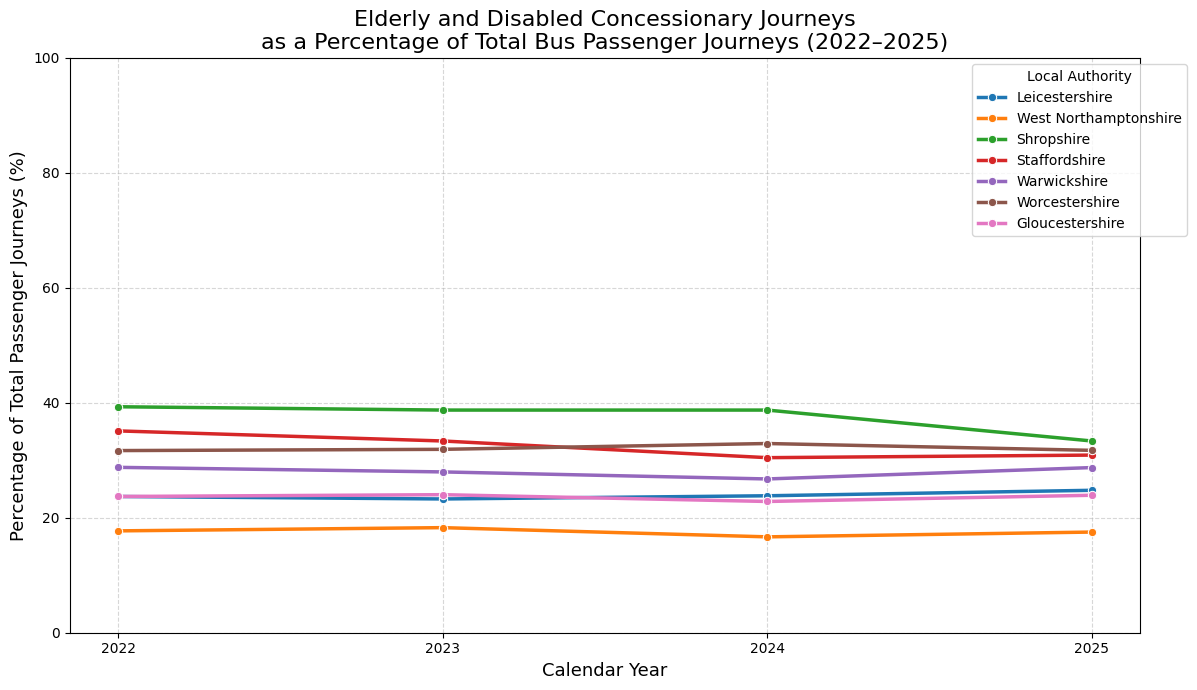

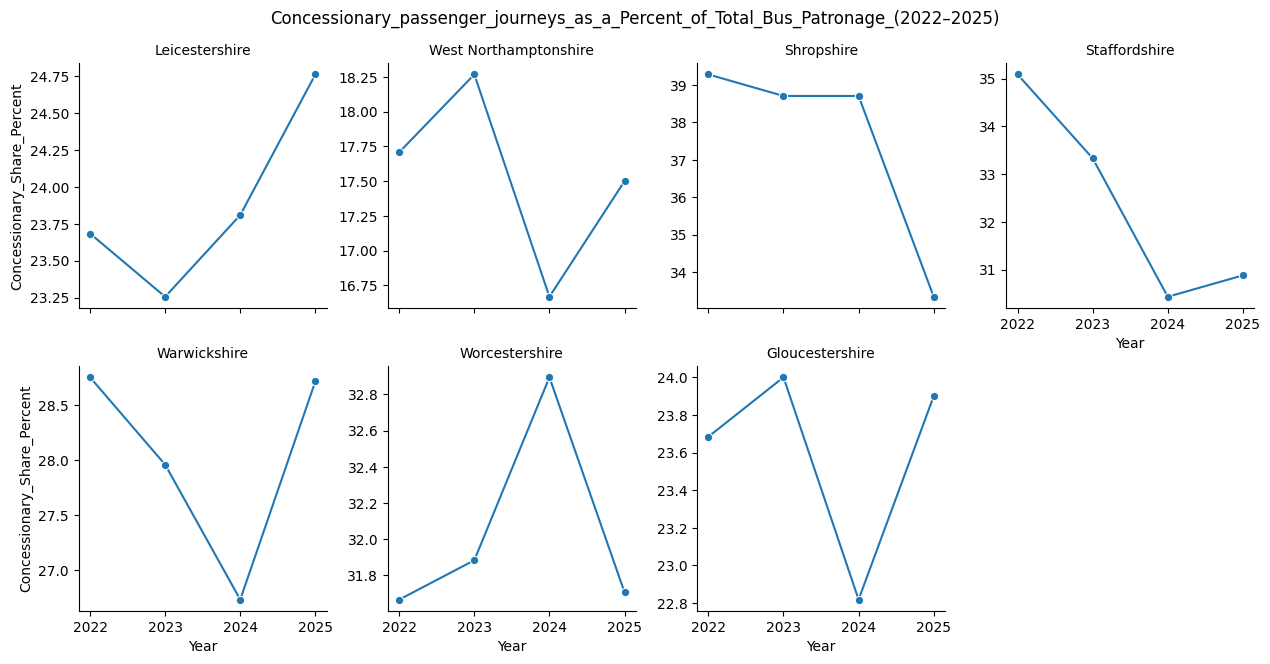

LA or Region,Gloucestershire,Leicestershire,Shropshire,Staffordshire,Warwickshire,West Northamptonshire,Worcestershire
Percentage change 2022–25,0.9%,4.5%,-15.2%,-12.0%,-0.1%,-1.2%,0.1%


In [43]:
bus01e = pd.read_csv("data/BUS01e.csv")
bus01g = pd.read_csv("data/BUS01g.csv")

year_cols = [c for c in bus01e.columns if c.isdigit()]

# Melt BUS01e (total journeys)
e_long = bus01e.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Total_Journeys"
)

# Melt BUS01g (concessionary journeys)
g_long = bus01g.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Concessionary_Journeys"
)

# Convert types 
e_long["Year"] = e_long["Year"].astype(int)
g_long["Year"] = g_long["Year"].astype(int)

e_long["Total_Journeys"] = pd.to_numeric(
    e_long["Total_Journeys"],
    errors="coerce"
)

g_long["Concessionary_Journeys"] = pd.to_numeric(
    g_long["Concessionary_Journeys"],
    errors="coerce"
)

# Merge
merged = pd.merge(
    e_long,
    g_long,
    on=["LA or Region", "Year"]
)


merged["Concessionary_Share_Percent"] = (
    merged["Concessionary_Journeys"] /
    merged["Total_Journeys"]
) * 100

# Filter years and authorities
merged = merged[merged["Year"].between(2022, 2025)]

target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

df_filtered = merged[merged["LA or Region"].isin(target_areas)]
# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Concessionary_Share_Percent",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Elderly and Disabled Concessionary Journeys\n"
    "as a Percentage of Total Bus Passenger Journeys (2022–2025)",
    fontsize=16
)

plt.xlabel("Calendar Year", fontsize=13)
plt.ylabel("Percentage of Total Passenger Journeys (%)", fontsize=13)
plt.ylim(0, 100)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1))

ax = plt.gca()

years = sorted(df_filtered["Year"].unique())
ax.set_xticks(years)
ax.set_xticklabels(years)

ax.xaxis.set_major_formatter(FuncFormatter(year_formatter))


plt.tight_layout()
plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Concessionary_Share_Percent", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Concessionary_passenger_journeys_as_a_Percent_of_Total_Bus_Patronage_(2022–2025)", y=1.03)

plt.show()

df_22_25 = df_filtered[df_filtered["Year"].isin([2022, 2025])]

pivot = df_22_25.pivot(
    index="Year",
    columns="LA or Region",
    values="Concessionary_Share_Percent"
)

pct_change = ((pivot.loc[2025] - pivot.loc[2022]) / pivot.loc[2022]) * 100

final_df = pct_change.to_frame("Percentage change 2022–25").T
final_df = final_df.round(2)

df_styled = (
    final_df
    .style
    .format("{:.1f}%")   # ← one decimal place + percent sign
    .apply(
        lambda col: ["background-color: grey"] * len(col)
        if col.name == "Warwickshire"
        else ["" for _ in col],
        axis=0
    )
)
df_styled


**Brief commentary on key findings detailing the performance of Warwickshire compared to other similar Local Authorities**
>All neighbouring authorities show some recovery or growth in patronage following the pandemic period, but the rate and consistency of this growth differs significantly across authorities. Warwickshire appears in the middle of the recovery performance as it exhibits moderate but fluctuating patronage over the 4 year period. Patronage falls in 2023, then rebounds in 2024, but is followed by a marginal decline in 2025. Warwickshire seems to lack the same growth of other authorities such as West Northamptonshire which rises drastically year on year. Leicestershire demonstrates a smooth upwards trend which outperforms Warwickshire.  
>The same trend is visible in the other graphs and Warwickshire appears in the mid range of patronages across all of the authorities. There has been a marginal decline in concessionary users in 2025 similar to other authorities like Warwickshire, whilst Gloucestershire had a concessionary decline in 2024 but seems to have regained to previous levels of patronage in 2025.